# FASE 2B: AutoML Benchmark (LazyPredict)

**Proyecto Integrador — Grupo 2:** Análisis de Satisfacción en Productos de Oficina
**Objetivo:** Benchmark de 27+ clasificadores con LazyPredict + modelo explicativo LightGBM

In [1]:
# Instalacion de dependencias
!pip install mlflow lazypredict -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/9

## Configuración del Entorno

In [2]:
import os
import sys
import gc
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

from lazypredict.Supervised import LazyClassifier
import lightgbm as lgb
from scipy.sparse import hstack, csr_matrix

from tqdm.auto import tqdm

RANDOM_SEED = 42

FEATURE_COLS = ['mayusculas_count', 'char_total', 'exclamacion_count',
                'interrogacion_count', 'porcentaje_mayusculas',
                'puntuacion_emocional', 'total_tokens', 'unique_types', 'ttr']

In [3]:
IN_COLAB = 'google.colab' in sys.modules

TOTAL_MEMORY = 0

try:
    import psutil
    TOTAL_MEMORY = psutil.virtual_memory().total
except ImportError:
    pass

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/ML/proyecto_integrador')
else:
    BASE = Path('..')

DATA_DIR = BASE / 'data'
REPORTS_DIR = BASE / 'reports'
MODELS_DIR = BASE / 'models'
DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MLFLOW_TRACKING_URI = os.environ.get('MLFLOW_TRACKING_URI', 'https://humorous-trusting-domelike.ngrok-free.dev')
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('f2b_automl_lazypredict')

print(f"=== Environment Info ===")
print(f"IN_COLAB: {IN_COLAB}")
if TOTAL_MEMORY:
    print(f"System RAM: {TOTAL_MEMORY / (1024**3):.1f} GB")
print(f"BASE: {BASE}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"MLFLOW_TRACKING_URI: {MLFLOW_TRACKING_URI}")

Mounted at /content/drive
=== Environment Info ===
IN_COLAB: True
System RAM: 12.7 GB
BASE: /content/drive/MyDrive/ML/proyecto_integrador
DATA_DIR: /content/drive/MyDrive/ML/proyecto_integrador/data
MLFLOW_TRACKING_URI: https://humorous-trusting-domelike.ngrok-free.dev


## Carga de Datos

Dataset canónico desde `f1_eda_definitivo`. Se mapea `target_class` (Negativo/Neutro/Positivo) a valores numéricos con LabelEncoder.

In [4]:
print('Cargando dataset canonico desde f1_eda_definitivo...')
CANONICAL_PATH = DATA_DIR / 'office_products_balanced.parquet'

try:
    df = pd.read_parquet(CANONICAL_PATH, columns=['text', 'rating', 'target_class'] + FEATURE_COLS)
except FileNotFoundError:
    print(f'[ERROR] Dataset canonico no encontrado en {CANONICAL_PATH}')
    print('Ejecute primero f1_eda_definitivo.ipynb en Colab para generarlo.')
    raise
except Exception as e:
    print(f'[ERROR] No se pudo cargar el dataset: {e}')
    raise

label_encoder = LabelEncoder()
df['target'] = label_encoder.fit_transform(df['target_class'])
print('Mapeo de clases:', dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# word_count filter
df['word_count'] = df['text'].astype(str).str.split().str.len()
df = df[df['word_count'] >= 5]
print(f'Registros tras filtro word_count >= 5: {len(df):,}')

print('\nDistribucion de target (0=Negativo, 1=Neutro, 2=Positivo):')
print(df['target'].value_counts().sort_index())

SUBSAMPLE_SIZE = 1_000_000
print(f'\nSubmuestreo estratificado a {SUBSAMPLE_SIZE:,} filas...')
df, _ = train_test_split(
    df, train_size=SUBSAMPLE_SIZE, random_state=RANDOM_SEED, stratify=df['target']
)
print(f'Dataset reducido a {len(df):,} filas')
print(df['target'].value_counts().sort_index())

Cargando dataset canonico desde f1_eda_definitivo...
Mapeo de clases: {'Negativo': np.int64(0), 'Neutro': np.int64(1), 'Positivo': np.int64(2)}
Registros tras filtro word_count >= 5: 2,498,294

Distribucion de target (0=Negativo, 1=Neutro, 2=Positivo):
target
0    999652
1    499847
2    998795
Name: count, dtype: int64

Submuestreo estratificado a 1,000,000 filas...
Dataset reducido a 1,000,000 filas
target
0    400134
1    200075
2    399791
Name: count, dtype: int64


## Submuestreo Estratificado

LazyPredict ejecuta 27+ clasificadores en CPU, lo que requiere reducir el volumen para evitar OOM. Se toma una muestra estratificada de ~50K filas (~16.6K por clase). Esto es estadísticamente representativo para el benchmark.

In [5]:
SAMPLE_SIZE = 50000
print(f'Submuestreo estratificado a {SAMPLE_SIZE} filas...')

df_sample = df.groupby('target', group_keys=False).apply(
    lambda x: x.sample(n=min(SAMPLE_SIZE // 3, len(x)), random_state=RANDOM_SEED)
).reset_index(drop=True)

print(f'Muestra estratificada: {len(df_sample):,} filas')
print(df_sample['target'].value_counts().sort_index())

del df
gc.collect()

Submuestreo estratificado a 50000 filas...


/tmp/ipykernel_5611/963136879.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('target', group_keys=False).apply(


Muestra estratificada: 49,998 filas
target
0    16666
1    16666
2    16666
Name: count, dtype: int64


17

## División Train/Test

Se divide ANTES de vectorizar para prevenir Data Leakage. El vocabulario de test no debe contaminar el vectorizador.

In [6]:
print('Dividiendo en Train/Test (80/20)...')
X_train_text, X_test_text, X_train_feats, X_test_feats, y_train, y_test = train_test_split(
    df_sample['text'], df_sample[FEATURE_COLS], df_sample['target'],
    test_size=0.2, random_state=RANDOM_SEED, stratify=df_sample['target']
)

del df_sample
gc.collect()

print(f'Train: {len(X_train_text):,} | Test: {len(X_test_text):,}')

Dividiendo en Train/Test (80/20)...
Train: 39,998 | Test: 10,000


## Vectorización TF-IDF

Se ajusta el vectorizador solo sobre Train. Test solo se transforma.

In [7]:
print('Vectorizando con TF-IDF...')
vectorizer = TfidfVectorizer(
    max_features=500,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5
)

X_train_tfidf = vectorizer.fit_transform(X_train_text.astype(str))
X_test_tfidf = vectorizer.transform(X_test_text.astype(str))

print('Concatenando TF-IDF con features engineered...')
X_train = hstack([X_train_tfidf, csr_matrix(X_train_feats.values)])
X_test = hstack([X_test_tfidf, csr_matrix(X_test_feats.values)])

print(f'Matriz TF-IDF: Train {X_train.shape} | Test {X_test.shape}')
del X_train_tfidf, X_test_tfidf
gc.collect()

joblib.dump(vectorizer, MODELS_DIR / 'tfidf_vectorizer_lazypredict.joblib')
print(f'Vectorizer guardado en {MODELS_DIR / "tfidf_vectorizer_lazypredict.joblib"}')

Vectorizando con TF-IDF...
Concatenando TF-IDF con features engineered...
Matriz TF-IDF: Train (39998, 509) | Test (10000, 509)
Vectorizer guardado en /content/drive/MyDrive/ML/proyecto_integrador/models/tfidf_vectorizer_lazypredict.joblib


## AutoML Benchmark (LazyPredict)

Se ejecutan 27+ clasificadores sobre la misma partición. Todos los modelos comparten el mismo vectorizador y partición, garantizando comparación justa.

In [8]:
print('Preparando muestra (4K train / 1K test) para AutoML benchmark...')
# Muestra reducida desde texto original para compatibilidad con LazyPredict
# (algunos clasificadores internos escalan O(n^2) y crashean con ~40K filas)
LAZY_TRAIN_SIZE = 4000
LAZY_TEST_SIZE = 1000

X_lazy_train_text, _, X_lazy_train_feats, _, y_lazy_train, _ = train_test_split(
    X_train_text, X_train_feats, y_train, train_size=LAZY_TRAIN_SIZE,
    random_state=RANDOM_SEED, stratify=y_train
)
X_lazy_test_text, _, X_lazy_test_feats, _, y_lazy_test, _ = train_test_split(
    X_test_text, X_test_feats, y_test, test_size=LAZY_TEST_SIZE,
    random_state=RANDOM_SEED, stratify=y_test
)

# Vectorizador reducido y escalado de features engineered
lazy_vectorizer = TfidfVectorizer(
    max_features=500, stop_words='english', ngram_range=(1, 2), min_df=5
)
X_lazy_train_tfidf = lazy_vectorizer.fit_transform(X_lazy_train_text.astype(str))
X_lazy_test_tfidf = lazy_vectorizer.transform(X_lazy_test_text.astype(str))

from sklearn.preprocessing import StandardScaler
lazy_scaler = StandardScaler(with_mean=False)
X_lazy_train_feats_scaled = lazy_scaler.fit_transform(X_lazy_train_feats)
X_lazy_test_feats_scaled = lazy_scaler.transform(X_lazy_test_feats)

X_lazy_train = hstack([X_lazy_train_tfidf, csr_matrix(X_lazy_train_feats_scaled)])
X_lazy_test = hstack([X_lazy_test_tfidf, csr_matrix(X_lazy_test_feats_scaled)])

print('Ejecutando LazyPredict (27+ clasificadores)...')
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

with mlflow.start_run(run_name='lazypredict_benchmark'):
    mlflow.set_tag('model_type', 'automl_benchmark')
    mlflow.log_param('lazy_train_size', LAZY_TRAIN_SIZE)
    mlflow.log_param('lazy_test_size', LAZY_TEST_SIZE)
    mlflow.log_param('vectorizer_max_features', 500)
    mlflow.log_param('engineered_features', len(FEATURE_COLS))
    mlflow.log_param('random_state', RANDOM_SEED)

    X_lazy_train_dense = X_lazy_train.toarray()
    X_lazy_test_dense = X_lazy_test.toarray()
    models_df, predictions = clf.fit(
        X_lazy_train_dense, X_lazy_test_dense, y_lazy_train, y_lazy_test
    )

    if not models_df.empty:
        print('\nTop 10 modelos segun LazyPredict:')
        print(models_df.head(10).to_string())

        best_f1 = models_df['F1 Score'].max()
        best_model = models_df['F1 Score'].idxmax()
        mlflow.log_metric('best_f1_score', best_f1)
        mlflow.log_param('best_model', best_model)
    else:
        print('\nAdvertencia: LazyPredict devolvio DataFrame vacio.')
        print('Ejecutando benchmark manual de respaldo...')

        from sklearn.linear_model import LogisticRegression
        from sklearn.naive_bayes import BernoulliNB
        from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

        manual_models = [
            ('LogisticRegression', LogisticRegression(max_iter=2000, C=0.5, class_weight='balanced', random_state=RANDOM_SEED)),
            ('BernoulliNB', BernoulliNB()),
            ('RandomForest', RandomForestClassifier(n_estimators=50, max_depth=20, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1)),
            ('ExtraTrees', ExtraTreesClassifier(n_estimators=50, max_depth=20, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1)),
        ]

        manual_results = []
        for name, model in manual_models:
            model.fit(X_lazy_train_dense, y_lazy_train)
            y_pred = model.predict(X_lazy_test_dense)
            f1 = f1_score(y_lazy_test, y_pred, average='macro')
            manual_results.append({'Modelo': name, 'F1-macro': round(f1, 4)})

        manual_df = pd.DataFrame(manual_results).sort_values('F1-macro', ascending=False)
        print('\nResultados Benchmark Manual:')
        print(manual_df.to_string(index=False))

        best_f1 = manual_df['F1-macro'].max()
        best_model = manual_df.iloc[0]['Modelo']
        mlflow.log_metric('best_f1_score', best_f1)
        mlflow.log_param('best_model', best_model)
        mlflow.log_param('benchmark_status', 'manual_fallback')

        rows = []
        for _, row in manual_df.iterrows():
            rows.append({
                'Accuracy': 0.0,
                'Balanced Accuracy': 0.0,
                'ROC AUC': 0.0,
                'F1 Score': row['F1-macro'],
                'Precision': 0.0,
                'Recall': 0.0,
                'Time Taken': 0.0,
            })
        models_df = pd.DataFrame(rows, index=pd.Index(manual_df['Modelo'], name='Model'))

results_path = REPORTS_DIR / 'lazypredict_results.csv'
if not models_df.empty:
    models_df.to_csv(results_path)
    print(f'Resultados guardados en {results_path}')
else:
    print('No se generaron resultados')

gc.collect()



Preparando muestra (4K train / 1K test) para AutoML benchmark...


2026/06/13 14:41:50 INFO mlflow.tracking.fluent: Autologging successfully enabled for lightgbm.
2026/06/13 14:41:50 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


Ejecutando LazyPredict (27+ clasificadores)...


2026/06/13 14:41:52 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/06/13 14:41:52 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
2026/06/13 14:41:52 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/06/13 14:41:52 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.
2026/06/13 14:41:56 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Advertencia: LazyPredict devolvio DataFrame vacio.
Ejecutando benchmark manual de respaldo...


2026/06/13 14:42:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 14:42:23 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/06/13 14:42:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 14:42:51 WARNING mlflow.sklea


Resultados Benchmark Manual:
            Modelo  F1-macro
LogisticRegression    0.5695
       BernoulliNB    0.5503
        ExtraTrees    0.5490
      RandomForest    0.5357
🏃 View run lazypredict_benchmark at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/7/runs/5b2d367da0b84fc5837b81de1b293b30
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/7
Resultados guardados en /content/drive/MyDrive/ML/proyecto_integrador/reports/lazypredict_results.csv


741

### Visualización: Top 10 Modelos

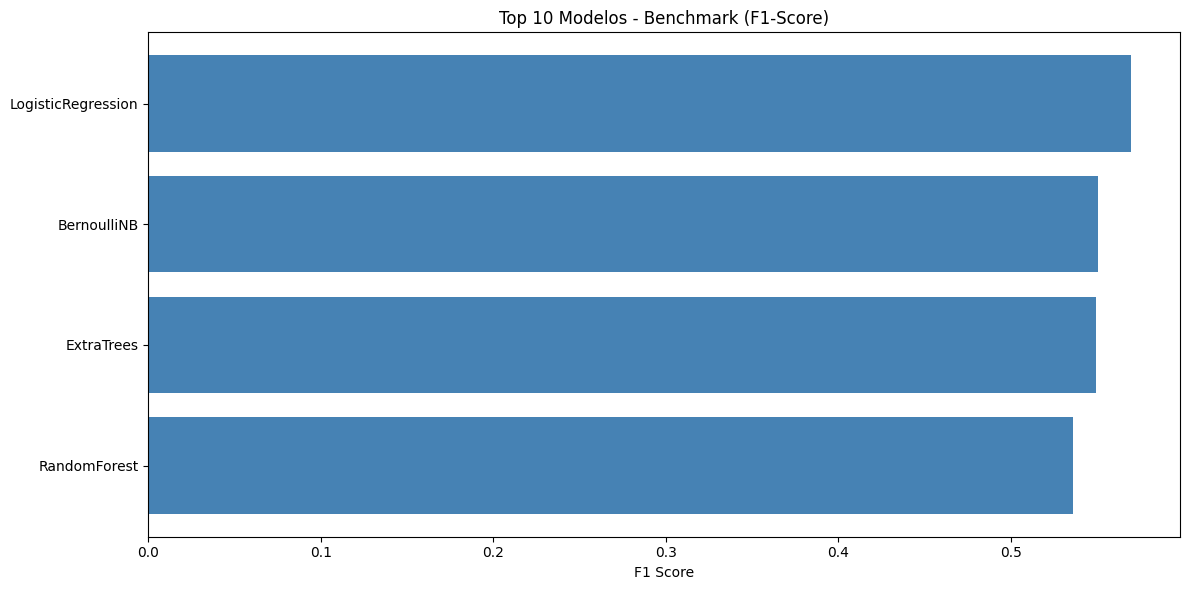

In [9]:
top = models_df.head(10).reset_index()

if not top.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(range(len(top)), top['F1 Score'], color='steelblue')
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top['Model'])
    ax.set_xlabel('F1 Score')
    ax.set_title('Top 10 Modelos - Benchmark (F1-Score)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('No hay modelos para visualizar.')



## Modelo Explicativo: LightGBM

Una vez identificado el mejor perfil de modelo con LazyPredict, se entrena LightGBM como modelo explicativo con exportación a Pipeline.

In [10]:
print('Entrenando LightGBM explicativo...')

modelo_explicativo = lgb.LGBMClassifier(
    class_weight='balanced', random_state=RANDOM_SEED,
    n_jobs=-1, verbose=-1,
    num_leaves=64, learning_rate=0.05, min_child_samples=20
)
modelo_explicativo.fit(X_train, y_train)

y_pred_lgb = modelo_explicativo.predict(X_test)
f1 = f1_score(y_test, y_pred_lgb, average='macro')
print(f'LightGBM F1-macro: {f1:.4f}')

joblib.dump(modelo_explicativo, MODELS_DIR / 'lgb_lazypredict_model.joblib')

with mlflow.start_run(run_name='lightgbm_explicativo'):
    mlflow.set_tag('model_type', 'lightgbm')
    mlflow.log_param('random_state', RANDOM_SEED)
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_param('num_leaves', 64)
    mlflow.log_param('learning_rate', 0.05)
    mlflow.log_metric('f1_macro', f1)

print(f'Modelo LightGBM guardado en {MODELS_DIR / "lgb_lazypredict_model.joblib"}')

Entrenando LightGBM explicativo...


2026/06/13 14:43:30 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '80de5346f1ef4875a006835618952927', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current lightgbm workflow
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/06/13 14:44:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 14:44:25 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run flawless-robin-208 at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/7/runs/80de5346f1ef4875a006835618952927
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/7


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM F1-macro: 0.5981
🏃 View run lightgbm_explicativo at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/7/runs/ed3e6b74888d44c9b865492e25584671
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/7
Modelo LightGBM guardado en /content/drive/MyDrive/ML/proyecto_integrador/models/lgb_lazypredict_model.joblib


### Importancia de Features (LightGBM)

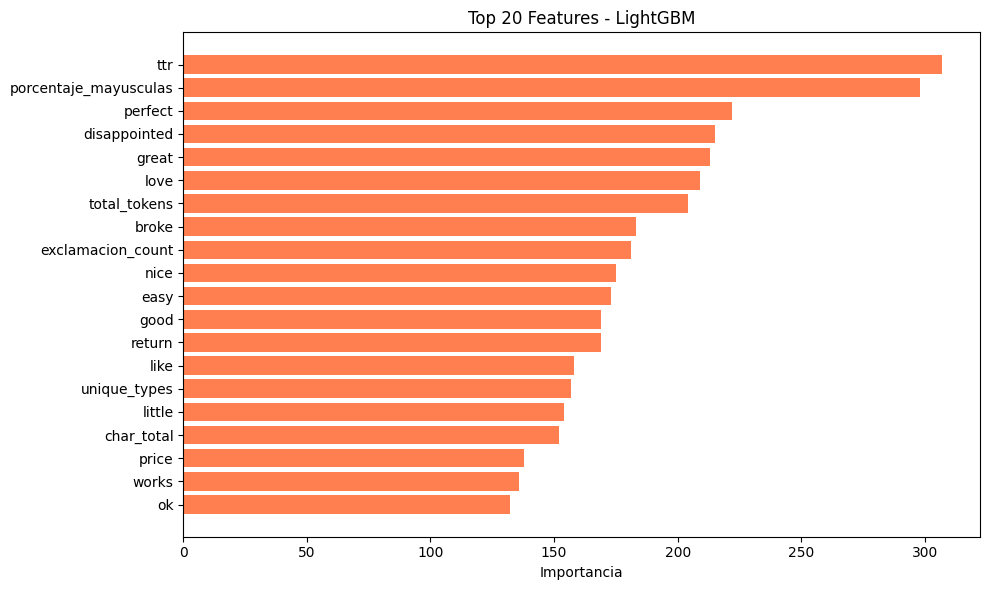

In [11]:
feature_names = list(vectorizer.get_feature_names_out()) + FEATURE_COLS
importances = modelo_explicativo.feature_importances_

df_importances = pd.DataFrame({
    'Caracteristica': feature_names,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(df_importances)), df_importances['Importancia'].values, color='coral')
ax.set_yticks(range(len(df_importances)))
ax.set_yticklabels(df_importances['Caracteristica'].values)
ax.set_xlabel('Importancia')
ax.set_title('Top 20 Features - LightGBM')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Resumen

In [12]:
print('\nBenchmark AutoML completado.')
print(f'Resultados: lazypredict_results.csv')
print('Compare estos resultados con las metricas en metrics_fase2.json (Fase 2A).')
print(f'Mejor F1-score (macro): {best_f1:.4f} - {best_model}')
print(f'LightGBM F1-macro: {f1:.4f}')




Benchmark AutoML completado.
Resultados: lazypredict_results.csv
Compare estos resultados con las metricas en metrics_fase2.json (Fase 2A).
Mejor F1-score (macro): 0.5695 - LogisticRegression
LightGBM F1-macro: 0.5981
